# Agricultural Subsidy Machine Learning

This notebook trains two models using only the **Balanced Dataset** sheet:

1. **Classification:** Predicts `Effectiveness Label` using a regularized Random Forest Classifier.
2. **Regression:** Predicts `Crop Yield (bags/ha)` using Random Forest Regressor.

### Classification outputs
- Accuracy
- Precision
- Recall / Sensitivity
- F1 Score
- Specificity
- Confusion Matrix
- Improved Learning Curve
- Classification Report
- Feature Importance
- 5-fold Cross-Validation

### Regression outputs
- MAE
- MSE
- RMSE
- R²
- Actual vs Predicted plot

**No external validation dataset is used.**

### Learning-curve improvement
The classifier is regularized to reduce excessive memorization, and the learning curve is calculated from the training split only. The final test set is kept separate for the final classification evaluation.


In [8]:
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

random.seed(42)
np.random.seed(42)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [9]:
# ============================================
# LOAD DATASET
# ============================================

DATASET_FILE = 'datasets/subsidy_dataset2_initial.xlsx'

df = pd.read_excel(
    DATASET_FILE,
    sheet_name='Balanced Dataset'
)

print('Dataset loaded successfully.')
print('Shape:', df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (798, 7)


,Farm Size (ha),Average Yield (bags/ha),Crop Yield (bags/ha),Average Selling Price (₱/kg),Feedback Score,Subsidy Received,Effectiveness Label
0,2.93,6.154111,160.0,20.05,2.7,Yes,Moderately Effective
1,0.80,6.154111,100.0,26.00,3.2,Yes,Moderately Effective
2,2.77,6.154111,170.0,20.12,1.7,Yes,Moderately Effective
3,1.23,6.154111,50.0,19.13,1.0,Yes,Not Effective
4,3.63,6.154111,180.0,17.33,3.2,Yes,Effective


In [10]:
# ============================================
# DATASET CHECK
# ============================================

print('Column Names:')
for column in df.columns:
    print('-', column)

print('\nMissing Values:')
print(df.isnull().sum())

print('\nDataset Shape:')
print(df.shape)

print('\nEffectiveness Label Distribution:')
print(df['Effectiveness Label'].value_counts())

print('\nSubsidy Distribution:')
print(df['Subsidy Received'].value_counts())

Column Names:
- Farm Size (ha)
- Average Yield (bags/ha)
- Crop Yield (bags/ha)
- Average Selling Price (₱/kg)
- Feedback Score
- Subsidy Received
- Effectiveness Label

Missing Values:
Farm Size (ha)                  0
Average Yield (bags/ha)         0
Crop Yield (bags/ha)            0
Average Selling Price (₱/kg)    0
Feedback Score                  0
Subsidy Received                0
Effectiveness Label             0
dtype: int64

Dataset Shape:
(798, 7)

Effectiveness Label Distribution:
Effectiveness Label
Moderately Effective    266
Not Effective           266
Effective               266
Name: count, dtype: int64

Subsidy Distribution:
Subsidy Received
Yes    575
No     223
Name: count, dtype: int64


## Part 1 — Classification

The classification model predicts `Effectiveness Label`.

In [11]:
# ============================================
# CLASSIFICATION FEATURES AND TARGET
# ============================================

TARGET_CLASS = 'Effectiveness Label'

X_class = df.drop(columns=[TARGET_CLASS])
y_class = df[TARGET_CLASS]

categorical_cols = ['Subsidy Received']

numerical_cols = [
    'Farm Size (ha)',
    'Average Yield (bags/ha)',
    'Crop Yield (bags/ha)',
    'Average Selling Price (₱/kg)',
    'Feedback Score'
]

print('Classification Features:')
print(X_class.columns.tolist())
print('\nTarget:', TARGET_CLASS)

Classification Features:
['Farm Size (ha)', 'Average Yield (bags/ha)', 'Crop Yield (bags/ha)', 'Average Selling Price (₱/kg)', 'Feedback Score', 'Subsidy Received']

Target: Effectiveness Label


In [12]:
# ============================================
# CLASSIFICATION PREPROCESSING
# ============================================

preprocessor_class = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

In [13]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    stratify=y_class,
    random_state=42
)

print('Training samples:', len(X_train_class))
print('Testing samples :', len(X_test_class))

Training samples: 638
Testing samples : 160


In [14]:
# ============================================
# RANDOM FOREST CLASSIFIER + REGULARIZED RANDOM SEARCH
# ============================================

# The original model allowed max_depth=None and min_samples_leaf=1.
# That can let individual trees memorize the training data, producing
# a 100% training score and a large train/validation gap.
#
# These parameter ranges add regularization while still allowing the
# Random Forest to learn useful nonlinear relationships.

classification_pipeline = Pipeline([
    ('preprocessor', preprocessor_class),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        bootstrap=True
    ))
])

params = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__max_depth': [5, 6, 7, 8],
    'classifier__min_samples_split': [5, 10, 15],
    'classifier__min_samples_leaf': [3, 5, 8],
    'classifier__max_features': ['sqrt'],
    'classifier__bootstrap': [True]
}

# Shuffle the folds so each fold is a representative stratified sample.
classification_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

search = RandomizedSearchCV(
    classification_pipeline,
    param_distributions=params,
    n_iter=20,
    cv=classification_cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

print('Training regularized classification model...')
search.fit(X_train_class, y_train_class)

classification_model = search.best_estimator_

print('\nTraining completed.')
print('Best Parameters:')
print(search.best_params_)
print(f'Best CV Accuracy: {search.best_score_ * 100:.2f}%')


Training regularized classification model...

Training completed.
Best Parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 15, 'classifier__min_samples_leaf': 3, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 7, 'classifier__bootstrap': True}
Best CV Accuracy: 90.91%


### Why the learning curve was changed

The previous learning curve showed **100% training accuracy** because the Random Forest search allowed unrestricted trees (`max_depth=None`) and very small leaves (`min_samples_leaf=1`). That configuration can memorize the training observations.

This version improves the methodology in three ways:

1. **Regularizes the Random Forest** by limiting tree depth and requiring more samples per leaf/split.
2. **Calculates the learning curve only on the training split**, keeping the final test set completely held out.
3. **Uses shuffled stratified 5-fold cross-validation** and displays the fold variability.

The goal is **not to artificially force the two curves to meet**. A reasonable learning curve should reflect the actual generalization behavior of the model. A smaller and stable train-validation gap is preferable to a perfect training score with a noticeably lower validation score.


In [15]:
# ============================================
# CLASSIFICATION PREDICTIONS
# ============================================

y_pred_class = classification_model.predict(X_test_class)

train_acc = classification_model.score(X_train_class, y_train_class)
test_acc = accuracy_score(y_test_class, y_pred_class)

print(f'Training Accuracy: {train_acc * 100:.2f}%')
print(f'Testing Accuracy : {test_acc * 100:.2f}%')

Training Accuracy: 96.39%
Testing Accuracy : 92.50%


In [16]:
# ============================================
# CLASSIFICATION METRICS
# ============================================

# Macro averaging treats each effectiveness class equally.
precision = precision_score(
    y_test_class,
    y_pred_class,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_test_class,
    y_pred_class,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_test_class,
    y_pred_class,
    average='macro',
    zero_division=0
)

print('============================================')
print('CLASSIFICATION EVALUATION METRICS')
print('============================================')
print(f'Accuracy   : {test_acc * 100:.2f}%')
print(f'Precision  : {precision * 100:.2f}%')
print(f'Recall     : {recall * 100:.2f}%')
print(f'F1 Score   : {f1 * 100:.2f}%')

CLASSIFICATION EVALUATION METRICS
Accuracy   : 92.50%
Precision  : 93.06%
Recall     : 92.53%
F1 Score   : 92.56%


In [17]:
# ============================================
# SPECIFICITY
# ============================================

# For multiclass classification, specificity is calculated
# one-vs-rest for every class, then macro-averaged.

labels = classification_model.classes_
cm = confusion_matrix(
    y_test_class,
    y_pred_class,
    labels=labels
)

specificities = []
specificity_rows = []

for i, label in enumerate(labels):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - (tp + fn + fp)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    specificities.append(specificity)

    specificity_rows.append({
        'Class': label,
        'Specificity': specificity
    })

macro_specificity = np.mean(specificities)

specificity_df = pd.DataFrame(specificity_rows)

print('Specificity by class:')
display(specificity_df)

print(f'Macro Specificity: {macro_specificity * 100:.2f}%')

Specificity by class:


,Class,Specificity
0,Effective,0.971963
1,Moderately Effective,0.915888
2,Not Effective,1.000000


Macro Specificity: 96.26%


In [18]:
# ============================================
# COMPLETE CLASSIFICATION SUMMARY
# ============================================

classification_summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Macro)',
        'Recall (Macro)',
        'F1 Score (Macro)',
        'Specificity (Macro)'
    ],
    'Value': [
        test_acc,
        precision,
        recall,
        f1,
        macro_specificity
    ],
    'Percentage': [
        test_acc * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        macro_specificity * 100
    ]
})

display(classification_summary)

classification_summary.to_excel(
    'classification_metrics.xlsx',
    index=False
)

,Metric,Value,Percentage
0,Accuracy,0.925000,92.500000
1,Precision (Macro),0.930634,93.063402
2,Recall (Macro),0.925344,92.534358
3,F1 Score (Macro),0.925607,92.560708
4,Specificity (Macro),0.962617,96.261682


In [19]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print(classification_report(
    y_test_class,
    y_pred_class,
    zero_division=0
))

                      precision    recall  f1-score   support

           Effective       0.94      0.96      0.95        53
Moderately Effective       0.85      0.94      0.89        53
       Not Effective       1.00      0.87      0.93        54

            accuracy                           0.93       160
           macro avg       0.93      0.93      0.93       160
        weighted avg       0.93      0.93      0.93       160



<Figure size 800x600 with 0 Axes>

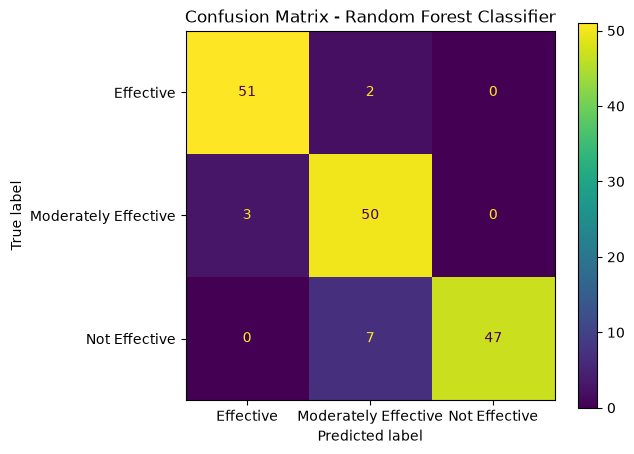

In [20]:
# ============================================
# CONFUSION MATRIX
# ============================================

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(values_format='d')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.tight_layout()

plt.savefig(
    'confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

LEARNING CURVE SUMMARY
Final Training Accuracy      : 96.67%
Final Cross-Validation Accuracy: 90.60%
Final Train-CV Gap            : 6.07 percentage points


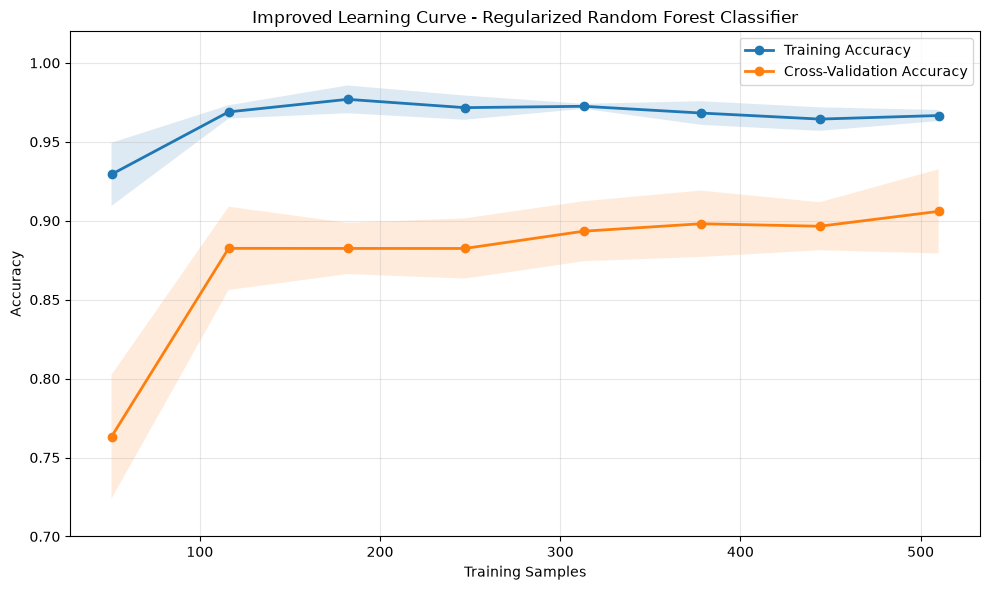

In [21]:
# ============================================
# IMPROVED LEARNING CURVE
# ============================================

# IMPORTANT:
# The learning curve is calculated using ONLY the training split.
# The held-out test set is not used here.
#
# This gives a cleaner estimate of how the model generalizes as more
# training data becomes available.

learning_curve_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes, train_scores, validation_scores = learning_curve(
    classification_model,
    X_train_class,
    y_train_class,
    cv=learning_curve_cv,
    train_sizes=np.linspace(0.10, 1.00, 8),
    scoring='accuracy',
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

# Final train-validation gap
final_gap = train_mean[-1] - validation_mean[-1]

print('============================================')
print('LEARNING CURVE SUMMARY')
print('============================================')
print(f'Final Training Accuracy      : {train_mean[-1] * 100:.2f}%')
print(f'Final Cross-Validation Accuracy: {validation_mean[-1] * 100:.2f}%')
print(f'Final Train-CV Gap            : {final_gap * 100:.2f} percentage points')

plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    validation_mean,
    marker='o',
    linewidth=2,
    label='Cross-Validation Accuracy'
)

# Show the variation across the 5 folds.
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel('Training Samples')
plt.ylabel('Accuracy')
plt.title('Improved Learning Curve - Regularized Random Forest Classifier')
plt.ylim(0.70, 1.02)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    'learning_curve_improved.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [22]:
# ============================================
# CROSS VALIDATION
# ============================================

# Evaluate cross-validation on the training portion only.
# The test set remains untouched until final evaluation.

cv_scores = cross_val_score(
    classification_model,
    X_train_class,
    y_train_class,
    cv=classification_cv,
    scoring='accuracy',
    n_jobs=-1
)

print('Cross Validation Scores:')
for i, score in enumerate(cv_scores, start=1):
    print(f'Fold {i}: {score * 100:.2f}%')

print(f'\nMean Cross Validation Accuracy: {cv_scores.mean() * 100:.2f}%')
print(f'Standard Deviation: {cv_scores.std() * 100:.2f}%')


Cross Validation Scores:
Fold 1: 94.53%
Fold 2: 87.50%
Fold 3: 89.84%
Fold 4: 93.70%
Fold 5: 88.98%

Mean Cross Validation Accuracy: 90.91%
Standard Deviation: 2.74%


In [23]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_names = (
    classification_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

feature_importances = (
    classification_model
    .named_steps['classifier']
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(
    by='Importance',
    ascending=False
)

print('Top 10 Most Important Features:')
display(feature_importance_df.head(10))

feature_importance_df.to_excel(
    'feature_importance.xlsx',
    index=False
)

Top 10 Most Important Features:


,Feature,Importance
4,num__Crop Yield (bags/ha),0.520762
6,num__Feedback Score,0.377038
2,num__Farm Size (ha),0.042914
5,num__Average Selling Price (₱/kg),0.038727
0,cat__Subsidy Received_No,0.010442
1,cat__Subsidy Received_Yes,0.010116
3,num__Average Yield (bags/ha),0.000000


## Part 2 — Regression

The regression model predicts `Crop Yield (bags/ha)`. MAE, MSE, RMSE, and R² are appropriate regression metrics.

In [24]:
# ============================================
# REGRESSION FEATURES AND TARGET
# ============================================

TARGET_REG = 'Crop Yield (bags/ha)'

X_reg = df.drop(columns=[TARGET_REG])
y_reg = df[TARGET_REG]

categorical_cols_reg = ['Subsidy Received']

numerical_cols_reg = [
    'Farm Size (ha)',
    'Average Yield (bags/ha)',
    'Average Selling Price (₱/kg)',
    'Feedback Score'
]

print('Regression Target:', TARGET_REG)
print('\nRegression Features:')
print(X_reg.columns.tolist())

Regression Target: Crop Yield (bags/ha)

Regression Features:
['Farm Size (ha)', 'Average Yield (bags/ha)', 'Average Selling Price (₱/kg)', 'Feedback Score', 'Subsidy Received', 'Effectiveness Label']


In [25]:
# ============================================
# REGRESSION TRAIN / TEST SPLIT
# ============================================

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print('Regression Training Samples:', len(X_train_reg))
print('Regression Testing Samples :', len(X_test_reg))

Regression Training Samples: 638
Regression Testing Samples : 160


In [26]:
# ============================================
# REGRESSION PREPROCESSING
# ============================================

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_reg),
        ('num', 'passthrough', numerical_cols_reg)
    ]
)

In [27]:
# ============================================
# RANDOM FOREST REGRESSOR
# ============================================

regression_model = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

print('Training regression model...')
regression_model.fit(X_train_reg, y_train_reg)
print('Regression training completed.')

Training regression model...
Regression training completed.


In [28]:
# ============================================
# REGRESSION EVALUATION
# ============================================

y_pred_reg = regression_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print('============================================')
print('REGRESSION EVALUATION')
print('============================================')
print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')

REGRESSION EVALUATION
MAE  : 54.1904
MSE  : 5396.2069
RMSE : 73.4589
R²   : 0.1410


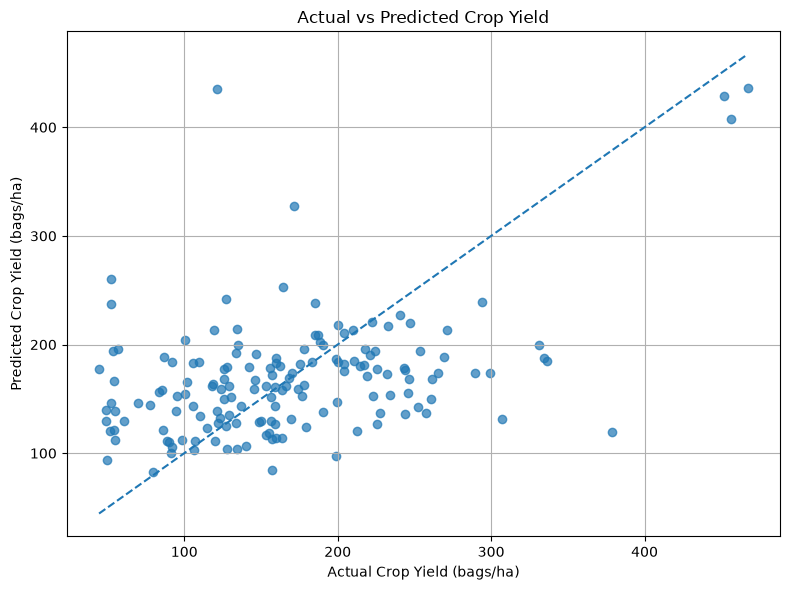

In [29]:
# ============================================
# ACTUAL VS PREDICTED CROP YIELD
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.7
)

minimum = min(y_test_reg.min(), y_pred_reg.min())
maximum = max(y_test_reg.max(), y_pred_reg.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle='--'
)

plt.xlabel('Actual Crop Yield (bags/ha)')
plt.ylabel('Predicted Crop Yield (bags/ha)')
plt.title('Actual vs Predicted Crop Yield')
plt.grid(True)
plt.tight_layout()

plt.savefig(
    'actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
# ============================================
# SAVE REGRESSION METRICS
# ============================================

regression_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae, mse, rmse, r2]
})

display(regression_metrics)

regression_metrics.to_excel(
    'regression_metrics.xlsx',
    index=False
)

,Metric,Value
0,MAE,54.190414
1,MSE,5396.206913
2,RMSE,73.458879
3,R2,0.140957


In [31]:
# ============================================
# SAVE MODELS
# ============================================

joblib.dump(
    classification_model,
    'random_forest_subsidy_classifier.pkl'
)

joblib.dump(
    regression_model,
    'random_forest_crop_yield_regressor.pkl'
)

print('Models saved successfully.')

Models saved successfully.


In [32]:
# ============================================
# FINAL OUTPUT SUMMARY
# ============================================

print('============================================')
print('TRAINING COMPLETE')
print('============================================')

print('\nCLASSIFICATION RESULTS')
print(f'Accuracy            : {test_acc * 100:.2f}%')
print(f'Precision (Macro)   : {precision * 100:.2f}%')
print(f'Recall (Macro)      : {recall * 100:.2f}%')
print(f'F1 Score (Macro)    : {f1 * 100:.2f}%')
print(f'Specificity (Macro) : {macro_specificity * 100:.2f}%')
print(f'CV Mean Accuracy    : {cv_scores.mean() * 100:.2f}%')

print('\nREGRESSION RESULTS')
print(f'MAE                 : {mae:.4f}')
print(f'MSE                 : {mse:.4f}')
print(f'RMSE                : {rmse:.4f}')
print(f'R²                  : {r2:.4f}')

print('\nGENERATED FILES')
print('- confusion_matrix.png')
print('- learning_curve_improved.png')
print('- actual_vs_predicted.png')
print('- classification_metrics.xlsx')
print('- regression_metrics.xlsx')
print('- feature_importance.xlsx')
print('- random_forest_subsidy_classifier.pkl')
print('- random_forest_crop_yield_regressor.pkl')


TRAINING COMPLETE

CLASSIFICATION RESULTS
Accuracy            : 92.50%
Precision (Macro)   : 93.06%
Recall (Macro)      : 92.53%
F1 Score (Macro)    : 92.56%
Specificity (Macro) : 96.26%
CV Mean Accuracy    : 90.91%

REGRESSION RESULTS
MAE                 : 54.1904
MSE                 : 5396.2069
RMSE                : 73.4589
R²                  : 0.1410

GENERATED FILES
- confusion_matrix.png
- learning_curve_improved.png
- actual_vs_predicted.png
- classification_metrics.xlsx
- regression_metrics.xlsx
- feature_importance.xlsx
- random_forest_subsidy_classifier.pkl
- random_forest_crop_yield_regressor.pkl
